# Few-Shot Industrial Defect Learning

This notebook extends the unsupervised feature-based anomaly detector using
a very small number of labelled defective images.

Experiments will use:

- 1 labelled example per defect type,
- 5 labelled examples per defect type,
- 10 labelled examples per defect type.

The unsupervised detector remains responsible for normal-versus-defective
detection. Few-shot learning is used to classify detected defects as:

- broken large,
- broken small,
- contamination.

Support images used for few-shot learning are removed from evaluation.

In [1]:
from pathlib import Path
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

PROJECT_ROOT = Path(r"D:\PROJECTS\ANOMALY DETECTION")
DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "mvtec_ad"

TORCH_CACHE = PROJECT_ROOT / "models" / "torch_cache"
os.environ["TORCH_HOME"] = str(TORCH_CACHE)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.mvtec_dataset import MVTecDataset
from src.models.feature_anomaly_detector import (
    FeatureAnomalyDetector,
)

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Project root: D:\PROJECTS\ANOMALY DETECTION
Dataset root: D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad
Device: cuda
GPU: NVIDIA GeForce GTX 1050


In [2]:
CATEGORY = "bottle"
IMAGE_SIZE = 256
BATCH_SIZE = 8

DEFECT_TYPES = [
    "broken_large",
    "broken_small",
    "contamination",
]

SHOT_COUNTS = [1, 5, 10]

MEMORY_BANK_PATH = (
    PROJECT_ROOT
    / "models"
    / "resnet18_memory_bank_bottle.pt"
)

CONFIGURATION_PATH = (
    PROJECT_ROOT
    / "models"
    / "feature_detector_bottle_config.json"
)

print("Category:", CATEGORY)
print("Defect types:", DEFECT_TYPES)
print("Shot counts:", SHOT_COUNTS)

Category: bottle
Defect types: ['broken_large', 'broken_small', 'contamination']
Shot counts: [1, 5, 10]


In [3]:
test_dataset = MVTecDataset(
    dataset_root=DATASET_ROOT,
    category=CATEGORY,
    split="test",
    image_size=IMAGE_SIZE,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Test images:", len(test_dataset))
print("Test batches:", len(test_loader))

Test images: 83
Test batches: 11


In [4]:
detector = FeatureAnomalyDetector.from_saved_files(
    memory_bank_path=MEMORY_BANK_PATH,
    configuration_path=CONFIGURATION_PATH,
    device=DEVICE,
)

detector.eval()

print("Detector loaded successfully.")
print("Memory-bank shape:", detector.memory_bank.shape)
print("Image threshold:", detector.image_score_threshold)
print("Pixel threshold:", detector.pixel_threshold)

Detector loaded successfully.
Memory-bank shape: torch.Size([10000, 128])
Image threshold: 0.7190231680870056
Pixel threshold: 0.6153336763381958


In [5]:
indices_by_defect_type = {
    defect_type: []
    for defect_type in DEFECT_TYPES
}

normal_indices = []

for dataset_index, sample_information in enumerate(
    test_dataset.samples
):
    defect_type = sample_information["defect_type"]

    if defect_type == "good":
        normal_indices.append(dataset_index)

    elif defect_type in indices_by_defect_type:
        indices_by_defect_type[defect_type].append(
            dataset_index
        )

print("Normal images:", len(normal_indices))

for defect_type in DEFECT_TYPES:
    print(
        f"{defect_type:<20}: "
        f"{len(indices_by_defect_type[defect_type])}"
    )

Normal images: 20
broken_large        : 20
broken_small        : 22
contamination       : 21


In [6]:
def create_few_shot_split(
    indices_by_class: dict[str, list[int]],
    shots_per_class: int,
    random_seed: int,
) -> tuple[dict[str, list[int]], dict[str, list[int]]]:
    """Create reproducible support and query sets.

    The support set contains the labelled few-shot examples.
    All remaining images form the query evaluation set.
    """

    random_generator = np.random.default_rng(
        random_seed
    )

    support_indices = {}
    query_indices = {}

    for defect_type, class_indices in (
        indices_by_class.items()
    ):
        class_indices_array = np.asarray(
            class_indices
        )

        shuffled_indices = random_generator.permutation(
            class_indices_array
        )

        support_indices[defect_type] = (
            shuffled_indices[:shots_per_class].tolist()
        )

        query_indices[defect_type] = (
            shuffled_indices[shots_per_class:].tolist()
        )

    return support_indices, query_indices

In [7]:
one_shot_support, one_shot_query = (
    create_few_shot_split(
        indices_by_class=indices_by_defect_type,
        shots_per_class=1,
        random_seed=RANDOM_SEED,
    )
)

print("ONE-SHOT SUPPORT AND QUERY SPLIT")

for defect_type in DEFECT_TYPES:
    print(f"\n{defect_type}")

    print(
        "  Support images:",
        len(one_shot_support[defect_type]),
    )

    print(
        "  Query images:",
        len(one_shot_query[defect_type]),
    )

    print(
        "  Support indices:",
        one_shot_support[defect_type],
    )

ONE-SHOT SUPPORT AND QUERY SPLIT

broken_large
  Support images: 1
  Query images: 19
  Support indices: [15]

broken_small
  Support images: 1
  Query images: 21
  Support indices: [29]

contamination
  Support images: 1
  Query images: 20
  Support indices: [55]


In [8]:
ANOMALOUS_PATCH_FRACTION = 0.05

print(
    "Anomalous patch fraction:",
    ANOMALOUS_PATCH_FRACTION,
)

Anomalous patch fraction: 0.05


In [9]:
def extract_defect_embeddings(
    detector: FeatureAnomalyDetector,
    images: torch.Tensor,
    anomalous_patch_fraction: float = 0.05,
) -> torch.Tensor:
    """Create one defect-focused embedding for each image.

    The procedure is:
    1. Extract frozen ResNet patch features.
    2. Measure every patch's distance from the normal memory bank.
    3. Select the most anomalous patches.
    4. Combine them using anomaly-distance weighting.
    5. L2-normalize the final embedding.
    """
    detector.eval()

    with torch.inference_mode():
        feature_maps = detector.feature_extractor(images)

        batch_size, channels, height, width = (
            feature_maps.shape
        )

        patch_features = (
            feature_maps
            .permute(0, 2, 3, 1)
            .reshape(batch_size, height * width, channels)
        )

        patch_features = F.normalize(
            patch_features,
            p=2,
            dim=2,
        )

        flattened_patch_features = patch_features.reshape(
            -1,
            channels,
        )

        patch_distances = (
            detector._nearest_normal_patch_distances(
                flattened_patch_features
            )
        )

        patch_distances = patch_distances.reshape(
            batch_size,
            height * width,
        )

        top_k_count = max(
            1,
            int(
                height
                * width
                * anomalous_patch_fraction
            ),
        )

        top_distances, top_indices = torch.topk(
            patch_distances,
            k=top_k_count,
            dim=1,
        )

        expanded_indices = top_indices.unsqueeze(-1).expand(
            -1,
            -1,
            channels,
        )

        top_patch_features = torch.gather(
            patch_features,
            dim=1,
            index=expanded_indices,
        )

        # More anomalous patches receive more weight.
        patch_weights = top_distances / (
            top_distances.sum(
                dim=1,
                keepdim=True,
            )
            + 1e-8
        )

        defect_embeddings = torch.sum(
            top_patch_features
            * patch_weights.unsqueeze(-1),
            dim=1,
        )

        defect_embeddings = F.normalize(
            defect_embeddings,
            p=2,
            dim=1,
        )

    return defect_embeddings

In [10]:
support_test_indices = [
    one_shot_support[defect_type][0]
    for defect_type in DEFECT_TYPES
]

support_test_samples = [
    test_dataset[index]
    for index in support_test_indices
]

support_test_images = torch.stack(
    [
        sample["image"]
        for sample in support_test_samples
    ]
).to(
    DEVICE,
    non_blocking=True,
)

support_test_embeddings = extract_defect_embeddings(
    detector=detector,
    images=support_test_images,
    anomalous_patch_fraction=(
        ANOMALOUS_PATCH_FRACTION
    ),
)

print(
    "Input image shape:",
    support_test_images.shape,
)

print(
    "Defect embedding shape:",
    support_test_embeddings.shape,
)

print(
    "Embedding device:",
    support_test_embeddings.device,
)

print(
    "Embedding norms:",
    support_test_embeddings.norm(
        dim=1
    ).tolist(),
)

Input image shape: torch.Size([3, 3, 256, 256])
Defect embedding shape: torch.Size([3, 128])
Embedding device: cuda:0
Embedding norms: [0.9999999403953552, 1.0, 1.0]


In [11]:
support_similarity_matrix = (
    support_test_embeddings
    @ support_test_embeddings.T
)

support_similarity_df = pd.DataFrame(
    support_similarity_matrix
    .detach()
    .cpu()
    .numpy(),
    index=DEFECT_TYPES,
    columns=DEFECT_TYPES,
)

support_similarity_df.round(4)

,broken_large,broken_small,contamination
broken_large,1.0000,0.8714,0.7579
broken_small,0.8714,1.0000,0.8418
contamination,0.7579,0.8418,1.0000


In [12]:
from torch.utils.data import DataLoader, Subset

all_defective_indices = []

for defect_type in DEFECT_TYPES:
    all_defective_indices.extend(
        indices_by_defect_type[defect_type]
    )

defective_dataset = Subset(
    test_dataset,
    all_defective_indices,
)

defective_loader = DataLoader(
    defective_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Defective images:", len(defective_dataset))
print("Defective batches:", len(defective_loader))

Defective images: 63
Defective batches: 8


In [13]:
from tqdm.auto import tqdm


def collect_defect_embeddings(
    detector: FeatureAnomalyDetector,
    data_loader: DataLoader,
    device: torch.device,
    anomalous_patch_fraction: float,
) -> tuple[torch.Tensor, pd.DataFrame]:
    """Extract embeddings and metadata for defective images."""

    collected_embeddings = []
    metadata_records = []

    for batch in tqdm(
        data_loader,
        desc="Extracting defect embeddings",
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        batch_embeddings = extract_defect_embeddings(
            detector=detector,
            images=images,
            anomalous_patch_fraction=(
                anomalous_patch_fraction
            ),
        )

        collected_embeddings.append(
            batch_embeddings.cpu()
        )

        for batch_index in range(images.size(0)):
            metadata_records.append(
                {
                    "image_path": batch["image_path"][
                        batch_index
                    ],
                    "defect_type": batch["defect_type"][
                        batch_index
                    ],
                    "label": int(
                        batch["label"][
                            batch_index
                        ].item()
                    ),
                }
            )

    embeddings = torch.cat(
        collected_embeddings,
        dim=0,
    )

    metadata = pd.DataFrame(
        metadata_records
    )

    return embeddings, metadata

d:\PROJECTS\ANOMALY DETECTION\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
all_defect_embeddings, defect_metadata_df = (
    collect_defect_embeddings(
        detector=detector,
        data_loader=defective_loader,
        device=DEVICE,
        anomalous_patch_fraction=(
            ANOMALOUS_PATCH_FRACTION
        ),
    )
)

print(
    "Embedding matrix shape:",
    all_defect_embeddings.shape,
)

print(
    "Metadata rows:",
    len(defect_metadata_df),
)

print(
    "\nDefect counts:"
)

print(
    defect_metadata_df[
        "defect_type"
    ].value_counts()
)

print(
    "\nEmbedding norm range:",
    all_defect_embeddings.norm(dim=1).min().item(),
    "to",
    all_defect_embeddings.norm(dim=1).max().item(),
)

Extracting defect embeddings: 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]

Embedding matrix shape: torch.Size([63, 128])
Metadata rows: 63

Defect counts:
defect_type
broken_small     22
contamination    21
broken_large     20
Name: count, dtype: int64

Embedding norm range: 0.9999999403953552 to 1.0000001192092896


In [15]:
defect_metadata_df["dataset_index"] = (
    all_defective_indices
)

defect_metadata_df.head()

,image_path,defect_type,label,dataset_index
0,D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_a...,broken_large,1,0
1,D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_a...,broken_large,1,1
2,D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_a...,broken_large,1,2
3,D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_a...,broken_large,1,3
4,D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_a...,broken_large,1,4


In [16]:
for row in defect_metadata_df.itertuples():
    expected_defect_type = test_dataset.samples[
        row.dataset_index
    ]["defect_type"]

    assert row.defect_type == expected_defect_type

print("Dataset indices verified successfully.")

Dataset indices verified successfully.


In [17]:
FEW_SHOT_EMBEDDINGS_PATH = (
    PROJECT_ROOT
    / "models"
    / "few_shot_bottle_defect_embeddings.pt"
)

torch.save(
    {
        "category": CATEGORY,
        "embedding_dimension": (
            all_defect_embeddings.shape[1]
        ),
        "anomalous_patch_fraction": (
            ANOMALOUS_PATCH_FRACTION
        ),
        "embeddings": all_defect_embeddings,
        "dataset_indices": defect_metadata_df[
            "dataset_index"
        ].tolist(),
        "defect_types": defect_metadata_df[
            "defect_type"
        ].tolist(),
        "image_paths": defect_metadata_df[
            "image_path"
        ].tolist(),
    },
    FEW_SHOT_EMBEDDINGS_PATH,
)

print("Few-shot embeddings saved to:")
print(FEW_SHOT_EMBEDDINGS_PATH)
print("File exists:", FEW_SHOT_EMBEDDINGS_PATH.exists())

Few-shot embeddings saved to:
D:\PROJECTS\ANOMALY DETECTION\models\few_shot_bottle_defect_embeddings.pt
File exists: True


In [18]:
embedding_position_by_dataset_index = {
    int(dataset_index): embedding_position
    for embedding_position, dataset_index in enumerate(
        defect_metadata_df["dataset_index"]
    )
}

class_index_by_name = {
    defect_type: class_index
    for class_index, defect_type in enumerate(
        DEFECT_TYPES
    )
}

class_name_by_index = {
    class_index: defect_type
    for defect_type, class_index in (
        class_index_by_name.items()
    )
}

print("Class mapping:")
print(class_index_by_name)

print(
    "Dataset-index lookup entries:",
    len(embedding_position_by_dataset_index),
)

Class mapping:
{'broken_large': 0, 'broken_small': 1, 'contamination': 2}
Dataset-index lookup entries: 63


In [19]:
def get_embeddings_from_dataset_indices(
    dataset_indices: list[int],
) -> torch.Tensor:
    """Retrieve saved embeddings using original dataset indices."""

    embedding_positions = [
        embedding_position_by_dataset_index[index]
        for index in dataset_indices
    ]

    return all_defect_embeddings[
        embedding_positions
    ]

In [20]:
example_indices = one_shot_support["broken_large"]

example_embeddings = get_embeddings_from_dataset_indices(
    example_indices
)

print("Example indices:", example_indices)
print("Embedding shape:", example_embeddings.shape)

Example indices: [15]
Embedding shape: torch.Size([1, 128])


In [21]:
def build_class_prototypes(
    support_indices: dict[str, list[int]],
) -> torch.Tensor:
    """Create one normalized prototype per defect class."""

    class_prototypes = []

    for defect_type in DEFECT_TYPES:
        support_embeddings = (
            get_embeddings_from_dataset_indices(
                support_indices[defect_type]
            )
        )

        prototype = support_embeddings.mean(
            dim=0,
            keepdim=True,
        )

        prototype = F.normalize(
            prototype,
            p=2,
            dim=1,
        )

        class_prototypes.append(prototype)

    return torch.cat(
        class_prototypes,
        dim=0,
    )

In [22]:
one_shot_prototypes = build_class_prototypes(
    one_shot_support
)

print(
    "One-shot prototype shape:",
    one_shot_prototypes.shape,
)

print(
    "Prototype norms:",
    one_shot_prototypes.norm(dim=1).tolist(),
)

One-shot prototype shape: torch.Size([3, 128])
Prototype norms: [1.0, 1.0, 1.0]


In [23]:
one_shot_prototype_similarity = (
    one_shot_prototypes
    @ one_shot_prototypes.T
)

one_shot_prototype_similarity_df = pd.DataFrame(
    one_shot_prototype_similarity.numpy(),
    index=DEFECT_TYPES,
    columns=DEFECT_TYPES,
)

one_shot_prototype_similarity_df.round(4)

,broken_large,broken_small,contamination
broken_large,1.0000,0.8714,0.7579
broken_small,0.8714,1.0000,0.8418
contamination,0.7579,0.8418,1.0000


In [24]:
one_shot_query_indices = []
one_shot_query_true_labels = []
one_shot_query_defect_types = []

for defect_type in DEFECT_TYPES:
    class_query_indices = one_shot_query[
        defect_type
    ]

    one_shot_query_indices.extend(
        class_query_indices
    )

    one_shot_query_true_labels.extend(
        [
            class_index_by_name[defect_type]
            for _ in class_query_indices
        ]
    )

    one_shot_query_defect_types.extend(
        [
            defect_type
            for _ in class_query_indices
        ]
    )

print(
    "Total query images:",
    len(one_shot_query_indices),
)

print(
    "Query label counts:",
    pd.Series(
        one_shot_query_defect_types
    ).value_counts(),
)

Total query images: 60
Query label counts: broken_small     21
contamination    20
broken_large     19
Name: count, dtype: int64


In [25]:
one_shot_query_embeddings = (
    get_embeddings_from_dataset_indices(
        one_shot_query_indices
    )
)

one_shot_similarity_scores = (
    one_shot_query_embeddings
    @ one_shot_prototypes.T
)

one_shot_predicted_labels = (
    one_shot_similarity_scores.argmax(dim=1)
)

one_shot_predicted_defect_types = [
    class_name_by_index[int(label)]
    for label in one_shot_predicted_labels
]

print(
    "Query embedding shape:",
    one_shot_query_embeddings.shape,
)

print(
    "Similarity matrix shape:",
    one_shot_similarity_scores.shape,
)

print(
    "Predicted images:",
    len(one_shot_predicted_labels),
)

Query embedding shape: torch.Size([60, 128])
Similarity matrix shape: torch.Size([60, 3])
Predicted images: 60


In [29]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

one_shot_true_labels = np.asarray(
    one_shot_query_true_labels
)

one_shot_predictions = (
    one_shot_predicted_labels.numpy()
)

one_shot_accuracy = accuracy_score(
    one_shot_true_labels,
    one_shot_predictions,
)

one_shot_macro_f1 = f1_score(
    one_shot_true_labels,
    one_shot_predictions,
    average="macro",
)

one_shot_weighted_f1 = f1_score(
    one_shot_true_labels,
    one_shot_predictions,
    average="weighted",
)

print("ONE-SHOT DEFECT CLASSIFICATION RESULTS")

print(f"Accuracy:     {one_shot_accuracy:.4f}")
print(f"Macro F1:     {one_shot_macro_f1:.4f}")
print(f"Weighted F1:  {one_shot_weighted_f1:.4f}")

print("\nClassification report:\n")

print(
    classification_report(
        one_shot_true_labels,
        one_shot_predictions,
        target_names=DEFECT_TYPES,
        digits=4,
        zero_division=0,
    )
)

ONE-SHOT DEFECT CLASSIFICATION RESULTS
Accuracy:     0.4167
Macro F1:     0.3333
Weighted F1:  0.3327

Classification report:

               precision    recall  f1-score   support

 broken_large     0.4194    0.6842    0.5200        19
 broken_small     0.4138    0.5714    0.4800        21
contamination     0.0000    0.0000    0.0000        20

     accuracy                         0.4167        60
    macro avg     0.2777    0.4185    0.3333        60
 weighted avg     0.2776    0.4167    0.3327        60



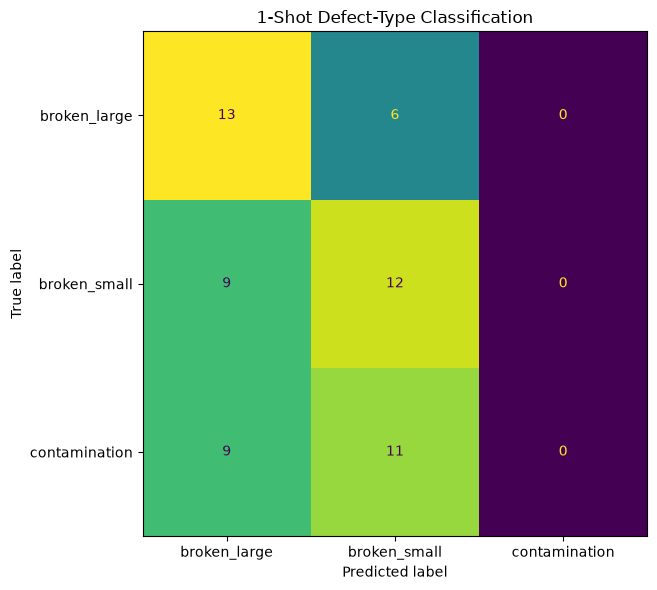

Confusion matrix saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\few_shot_1_shot_confusion_matrix.png


In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

one_shot_confusion_matrix = confusion_matrix(
    one_shot_true_labels,
    one_shot_predictions,
    labels=[0, 1, 2],
)

figure, axis = plt.subplots(
    figsize=(7, 6)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=one_shot_confusion_matrix,
    display_labels=DEFECT_TYPES,
)

display.plot(
    ax=axis,
    values_format="d",
    colorbar=False,
)

axis.set_title(
    "1-Shot Defect-Type Classification"
)

plt.xticks(rotation=0)
plt.tight_layout()

one_shot_confusion_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "few_shot_1_shot_confusion_matrix.png"
)

plt.savefig(
    one_shot_confusion_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Confusion matrix saved to:\n"
    f"{one_shot_confusion_path}"
)

In [32]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    recall_score,
)


def evaluate_few_shot_split(
    shots_per_class: int,
    random_seed: int,
) -> tuple[dict, np.ndarray]:
    """Evaluate one support/query split.

    Support images are used to construct class prototypes.
    Remaining images are used as the query evaluation set.
    """

    support_indices, query_indices = (
        create_few_shot_split(
            indices_by_class=indices_by_defect_type,
            shots_per_class=shots_per_class,
            random_seed=random_seed,
        )
    )

    prototypes = build_class_prototypes(
        support_indices
    )

    query_dataset_indices = []
    query_true_labels = []

    for defect_type in DEFECT_TYPES:
        class_query_indices = query_indices[
            defect_type
        ]

        query_dataset_indices.extend(
            class_query_indices
        )

        query_true_labels.extend(
            [
                class_index_by_name[defect_type]
                for _ in class_query_indices
            ]
        )

    query_embeddings = (
        get_embeddings_from_dataset_indices(
            query_dataset_indices
        )
    )

    similarity_scores = (
        query_embeddings @ prototypes.T
    )

    predicted_labels = (
        similarity_scores.argmax(dim=1).numpy()
    )

    true_labels = np.asarray(
        query_true_labels
    )

    per_class_recall = recall_score(
        true_labels,
        predicted_labels,
        labels=[0, 1, 2],
        average=None,
        zero_division=0,
    )

    confusion = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=[0, 1, 2],
    )

    metrics = {
        "shots": shots_per_class,
        "seed": random_seed,
        "query_images": len(true_labels),
        "accuracy": accuracy_score(
            true_labels,
            predicted_labels,
        ),
        "macro_f1": f1_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0,
        ),
        "recall_broken_large": (
            per_class_recall[0]
        ),
        "recall_broken_small": (
            per_class_recall[1]
        ),
        "recall_contamination": (
            per_class_recall[2]
        ),
    }

    return metrics, confusion

In [35]:
verification_metrics, verification_confusion = (
    evaluate_few_shot_split(
        shots_per_class=1,
        random_seed=RANDOM_SEED,
    )
)

print("Verification metrics:")

for metric_name, metric_value in (
    verification_metrics.items()
):
    print(f"{metric_name:<28}: {metric_value}")

print("\nConfusion matrix:")
print(verification_confusion)

Verification metrics:
shots                       : 1
seed                        : 42
query_images                : 60
accuracy                    : 0.4166666666666667
macro_f1                    : 0.3333333333333333
weighted_f1                 : 0.33266666666666667
recall_broken_large         : 0.6842105263157895
recall_broken_small         : 0.5714285714285714
recall_contamination        : 0.0

Confusion matrix:
[[13  6  0]
 [ 9 12  0]
 [ 9 11  0]]


In [36]:
EVALUATION_SEEDS = list(range(20))

few_shot_records = []

aggregate_confusion_matrices = {
    shot_count: np.zeros(
        (len(DEFECT_TYPES), len(DEFECT_TYPES)),
        dtype=np.int64,
    )
    for shot_count in SHOT_COUNTS
}

for shot_count in SHOT_COUNTS:
    for evaluation_seed in EVALUATION_SEEDS:
        metrics, confusion = (
            evaluate_few_shot_split(
                shots_per_class=shot_count,
                random_seed=evaluation_seed,
            )
        )

        few_shot_records.append(metrics)

        aggregate_confusion_matrices[
            shot_count
        ] += confusion

few_shot_results_df = pd.DataFrame(
    few_shot_records
)

print(
    "Completed experiments:",
    len(few_shot_results_df),
)

few_shot_results_df.head()

Completed experiments: 60


,shots,seed,query_images,accuracy,macro_f1,weighted_f1,recall_broken_large,recall_broken_small,recall_contamination
0,1,0,60,0.316667,0.235043,0.230128,0.789474,0.190476,0.00
1,1,1,60,0.416667,0.368685,0.367695,0.789474,0.380952,0.10
2,1,2,60,0.566667,0.565002,0.566416,0.578947,0.666667,0.45
3,1,3,60,0.533333,0.529271,0.526357,0.736842,0.285714,0.60
4,1,4,60,0.533333,0.513310,0.514008,0.736842,0.619048,0.25


In [37]:
few_shot_summary_df = (
    few_shot_results_df
    .groupby("shots")
    .agg(
        runs=("seed", "count"),
        query_images_mean=(
            "query_images",
            "mean",
        ),
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        accuracy_std=(
            "accuracy",
            "std",
        ),
        macro_f1_mean=(
            "macro_f1",
            "mean",
        ),
        macro_f1_std=(
            "macro_f1",
            "std",
        ),
        weighted_f1_mean=(
            "weighted_f1",
            "mean",
        ),
        weighted_f1_std=(
            "weighted_f1",
            "std",
        ),
        broken_large_recall_mean=(
            "recall_broken_large",
            "mean",
        ),
        broken_small_recall_mean=(
            "recall_broken_small",
            "mean",
        ),
        contamination_recall_mean=(
            "recall_contamination",
            "mean",
        ),
    )
    .reset_index()
)

display_few_shot_summary_df = (
    few_shot_summary_df.copy()
)

columns_to_round = [
    "query_images_mean",
    "accuracy_mean",
    "accuracy_std",
    "macro_f1_mean",
    "macro_f1_std",
    "weighted_f1_mean",
    "weighted_f1_std",
    "broken_large_recall_mean",
    "broken_small_recall_mean",
    "contamination_recall_mean",
]

display_few_shot_summary_df[
    columns_to_round
] = display_few_shot_summary_df[
    columns_to_round
].round(4)

display_few_shot_summary_df

,shots,runs,query_images_mean,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,broken_large_recall_mean,broken_small_recall_mean,contamination_recall_mean
0,1,20,60.0,0.4733,0.0937,0.4517,0.1145,0.4521,0.1145,0.6263,0.4905,0.3100
1,5,20,48.0,0.6417,0.0481,0.6382,0.0480,0.6397,0.0475,0.7167,0.6471,0.5656
2,10,20,33.0,0.7091,0.0633,0.7079,0.0675,0.7106,0.0670,0.7550,0.7500,0.6227


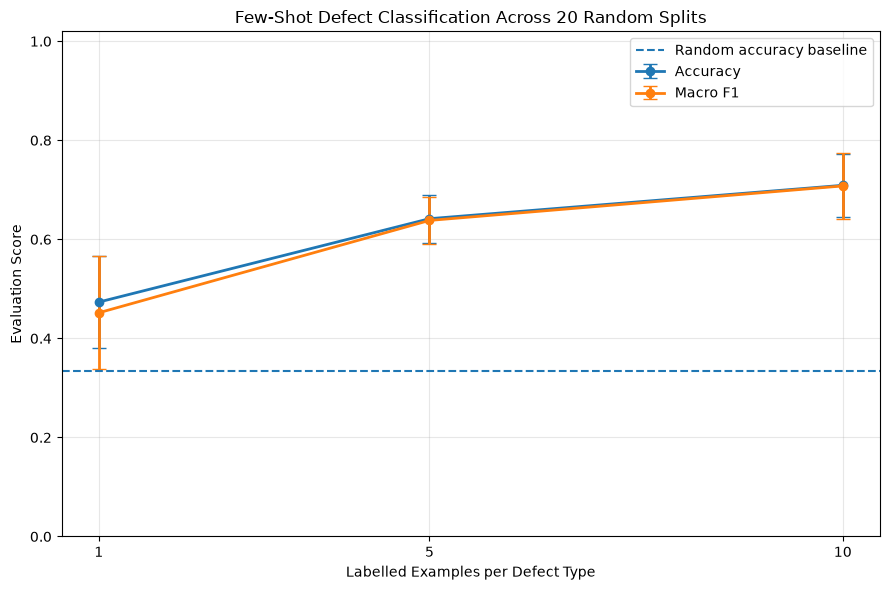

Few-shot performance figure saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\few_shot_performance_curve.png


In [38]:
plt.figure(figsize=(9, 6))

plt.errorbar(
    few_shot_summary_df["shots"],
    few_shot_summary_df["accuracy_mean"],
    yerr=few_shot_summary_df["accuracy_std"],
    marker="o",
    capsize=5,
    linewidth=2,
    label="Accuracy",
)

plt.errorbar(
    few_shot_summary_df["shots"],
    few_shot_summary_df["macro_f1_mean"],
    yerr=few_shot_summary_df["macro_f1_std"],
    marker="o",
    capsize=5,
    linewidth=2,
    label="Macro F1",
)

plt.axhline(
    1 / len(DEFECT_TYPES),
    linestyle="--",
    label="Random accuracy baseline",
)

plt.xticks(SHOT_COUNTS)
plt.xlabel("Labelled Examples per Defect Type")
plt.ylabel("Evaluation Score")
plt.title(
    "Few-Shot Defect Classification Across 20 Random Splits"
)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

few_shot_curve_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "few_shot_performance_curve.png"
)

plt.savefig(
    few_shot_curve_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Few-shot performance figure saved to:\n"
    f"{few_shot_curve_path}"
)

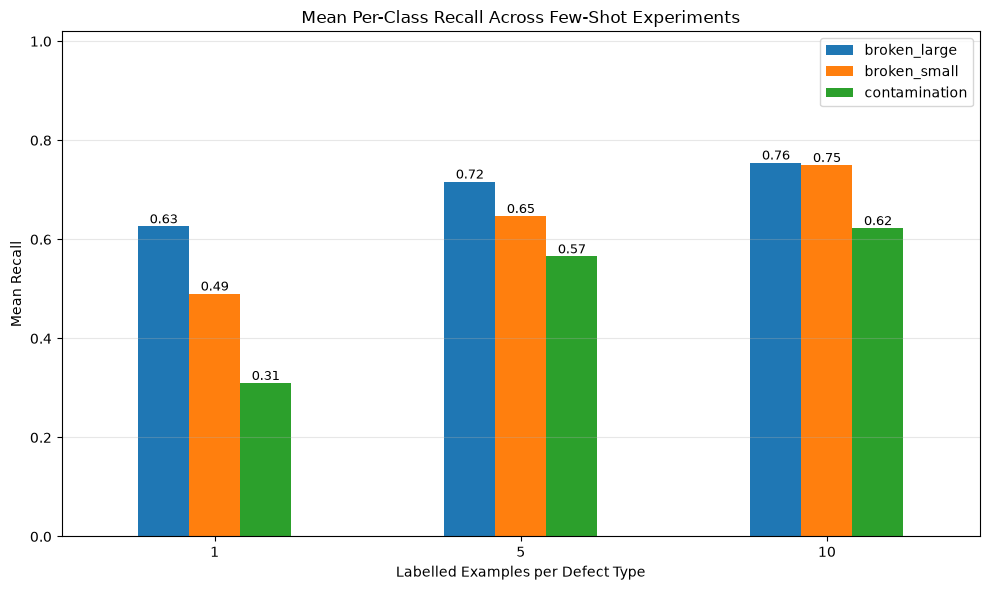

Per-class recall figure saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\few_shot_per_class_recall.png


In [40]:
recall_plot_df = (
    few_shot_summary_df[
        [
            "shots",
            "broken_large_recall_mean",
            "broken_small_recall_mean",
            "contamination_recall_mean",
        ]
    ]
    .set_index("shots")
    .rename(
        columns={
            "broken_large_recall_mean": (
                "broken_large"
            ),
            "broken_small_recall_mean": (
                "broken_small"
            ),
            "contamination_recall_mean": (
                "contamination"
            ),
        }
    )
)

axis = recall_plot_df.plot(
    kind="bar",
    figsize=(10, 6),
)

axis.set_title(
    "Mean Per-Class Recall Across Few-Shot Experiments"
)

axis.set_xlabel(
    "Labelled Examples per Defect Type"
)

axis.set_ylabel("Mean Recall")
axis.set_ylim(0, 1.02)
axis.grid(axis="y", alpha=0.3)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.2f",
        label_type="edge",
        fontsize=9,
    )
plt.xticks(rotation=0)
plt.tight_layout()

few_shot_recall_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "few_shot_per_class_recall.png"
)

plt.savefig(
    few_shot_recall_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Per-class recall figure saved to:\n"
    f"{few_shot_recall_path}"
)

In [41]:
few_shot_results_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "few_shot_repeated_results.csv"
)

few_shot_summary_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "few_shot_summary.csv"
)

few_shot_results_df.to_csv(
    few_shot_results_path,
    index=False,
)

few_shot_summary_df.to_csv(
    few_shot_summary_path,
    index=False,
)

print("Repeated results saved to:")
print(few_shot_results_path)

print("\nSummary saved to:")
print(few_shot_summary_path)

Repeated results saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\few_shot_repeated_results.csv

Summary saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\few_shot_summary.csv


In [42]:
FIXED_QUERY_IMAGES_PER_CLASS = 10
MAXIMUM_SHOTS = max(SHOT_COUNTS)


def create_fixed_query_split(
    indices_by_class: dict[str, list[int]],
    query_images_per_class: int,
    maximum_shots: int,
    random_seed: int,
) -> tuple[dict[str, list[int]], dict[str, list[int]]]:
    """Create one fixed query set and a separate support pool.

    The same query images are used for every shot count within a seed.
    """

    random_generator = np.random.default_rng(
        random_seed
    )

    query_indices = {}
    support_pools = {}

    for defect_type, class_indices in indices_by_class.items():
        required_images = (
            query_images_per_class + maximum_shots
        )

        if len(class_indices) < required_images:
            raise ValueError(
                f"{defect_type} has {len(class_indices)} images, "
                f"but at least {required_images} are required."
            )

        shuffled_indices = random_generator.permutation(
            class_indices
        ).tolist()

        query_indices[defect_type] = shuffled_indices[
            :query_images_per_class
        ]

        support_pools[defect_type] = shuffled_indices[
            query_images_per_class:
        ]

    return query_indices, support_pools

In [43]:
def evaluate_fixed_query_few_shot(
    query_indices: dict[str, list[int]],
    support_pools: dict[str, list[int]],
    shots_per_class: int,
    random_seed: int,
) -> tuple[dict, np.ndarray]:
    """Evaluate prototypes using a fixed query set."""

    support_indices = {
        defect_type: support_pools[defect_type][
            :shots_per_class
        ]
        for defect_type in DEFECT_TYPES
    }

    prototypes = build_class_prototypes(
        support_indices
    )

    flattened_query_indices = []
    query_true_labels = []

    for defect_type in DEFECT_TYPES:
        class_query_indices = query_indices[
            defect_type
        ]

        flattened_query_indices.extend(
            class_query_indices
        )

        query_true_labels.extend(
            [
                class_index_by_name[defect_type]
                for _ in class_query_indices
            ]
        )

    query_embeddings = (
        get_embeddings_from_dataset_indices(
            flattened_query_indices
        )
    )

    similarity_scores = (
        query_embeddings @ prototypes.T
    )

    predicted_labels = (
        similarity_scores.argmax(dim=1).numpy()
    )

    true_labels = np.asarray(
        query_true_labels
    )

    per_class_recall = recall_score(
        true_labels,
        predicted_labels,
        labels=[0, 1, 2],
        average=None,
        zero_division=0,
    )

    confusion = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=[0, 1, 2],
    )

    metrics = {
        "shots": shots_per_class,
        "seed": random_seed,
        "query_images": len(true_labels),
        "accuracy": accuracy_score(
            true_labels,
            predicted_labels,
        ),
        "macro_f1": f1_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0,
        ),
        "recall_broken_large": per_class_recall[0],
        "recall_broken_small": per_class_recall[1],
        "recall_contamination": per_class_recall[2],
    }

    return metrics, confusion

In [44]:
fixed_query_indices, fixed_support_pools = (
    create_fixed_query_split(
        indices_by_class=indices_by_defect_type,
        query_images_per_class=(
            FIXED_QUERY_IMAGES_PER_CLASS
        ),
        maximum_shots=MAXIMUM_SHOTS,
        random_seed=RANDOM_SEED,
    )
)

print("Fixed query and support-pool sizes:\n")

for defect_type in DEFECT_TYPES:
    print(defect_type)
    print(
        "  Query images:",
        len(fixed_query_indices[defect_type]),
    )
    print(
        "  Support-pool images:",
        len(fixed_support_pools[defect_type]),
    )

Fixed query and support-pool sizes:

broken_large
  Query images: 10
  Support-pool images: 10
broken_small
  Query images: 10
  Support-pool images: 12
contamination
  Query images: 10
  Support-pool images: 11


In [45]:
fixed_query_records = []

fixed_query_confusions = {
    shot_count: np.zeros(
        (len(DEFECT_TYPES), len(DEFECT_TYPES)),
        dtype=np.int64,
    )
    for shot_count in SHOT_COUNTS
}

for evaluation_seed in EVALUATION_SEEDS:
    query_indices, support_pools = (
        create_fixed_query_split(
            indices_by_class=indices_by_defect_type,
            query_images_per_class=(
                FIXED_QUERY_IMAGES_PER_CLASS
            ),
            maximum_shots=MAXIMUM_SHOTS,
            random_seed=evaluation_seed,
        )
    )

    for shot_count in SHOT_COUNTS:
        metrics, confusion = (
            evaluate_fixed_query_few_shot(
                query_indices=query_indices,
                support_pools=support_pools,
                shots_per_class=shot_count,
                random_seed=evaluation_seed,
            )
        )

        fixed_query_records.append(metrics)

        fixed_query_confusions[
            shot_count
        ] += confusion

fixed_query_results_df = pd.DataFrame(
    fixed_query_records
)

print(
    "Completed fixed-query experiments:",
    len(fixed_query_results_df),
)

print(
    "Unique query-set sizes:",
    fixed_query_results_df["query_images"].unique(),
)

Completed fixed-query experiments: 60
Unique query-set sizes: [30]


In [46]:
fixed_query_summary_df = (
    fixed_query_results_df
    .groupby("shots")
    .agg(
        runs=("seed", "count"),
        query_images=("query_images", "mean"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        weighted_f1_mean=("weighted_f1", "mean"),
        weighted_f1_std=("weighted_f1", "std"),
        broken_large_recall_mean=(
            "recall_broken_large",
            "mean",
        ),
        broken_small_recall_mean=(
            "recall_broken_small",
            "mean",
        ),
        contamination_recall_mean=(
            "recall_contamination",
            "mean",
        ),
    )
    .reset_index()
)

display_fixed_query_summary_df = (
    fixed_query_summary_df.copy()
)

columns_to_round = [
    "query_images",
    "accuracy_mean",
    "accuracy_std",
    "macro_f1_mean",
    "macro_f1_std",
    "weighted_f1_mean",
    "weighted_f1_std",
    "broken_large_recall_mean",
    "broken_small_recall_mean",
    "contamination_recall_mean",
]

display_fixed_query_summary_df[
    columns_to_round
] = display_fixed_query_summary_df[
    columns_to_round
].round(4)

display_fixed_query_summary_df

,shots,runs,query_images,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,broken_large_recall_mean,broken_small_recall_mean,contamination_recall_mean
0,1,20,30.0,0.4550,0.1033,0.4090,0.1178,0.4090,0.1178,0.680,0.470,0.215
1,5,20,30.0,0.6517,0.0952,0.6403,0.1108,0.6403,0.1108,0.760,0.660,0.535
2,10,20,30.0,0.7117,0.0695,0.7062,0.0795,0.7062,0.0795,0.855,0.645,0.635


In [47]:
fixed_query_results_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "few_shot_fixed_query_results.csv"
)

fixed_query_summary_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "few_shot_fixed_query_summary.csv"
)

fixed_query_results_df.to_csv(
    fixed_query_results_path,
    index=False,
)

fixed_query_summary_df.to_csv(
    fixed_query_summary_path,
    index=False,
)

print("Fixed-query results saved to:")
print(fixed_query_results_path)

print("\nFixed-query summary saved to:")
print(fixed_query_summary_path)

Fixed-query results saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\few_shot_fixed_query_results.csv

Fixed-query summary saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\few_shot_fixed_query_summary.csv


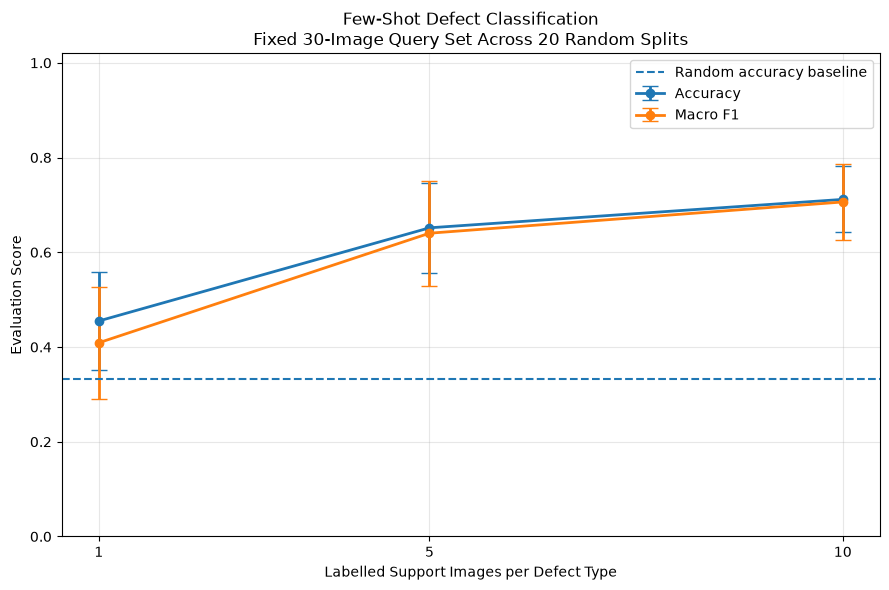

Fixed-query performance figure saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\few_shot_fixed_query_performance.png


In [48]:
plt.figure(figsize=(9, 6))

plt.errorbar(
    fixed_query_summary_df["shots"],
    fixed_query_summary_df["accuracy_mean"],
    yerr=fixed_query_summary_df["accuracy_std"],
    marker="o",
    linewidth=2,
    capsize=6,
    label="Accuracy",
)

plt.errorbar(
    fixed_query_summary_df["shots"],
    fixed_query_summary_df["macro_f1_mean"],
    yerr=fixed_query_summary_df["macro_f1_std"],
    marker="o",
    linewidth=2,
    capsize=6,
    label="Macro F1",
)

plt.axhline(
    1 / len(DEFECT_TYPES),
    linestyle="--",
    label="Random accuracy baseline",
)

plt.xticks(SHOT_COUNTS)
plt.xlabel("Labelled Support Images per Defect Type")
plt.ylabel("Evaluation Score")
plt.title(
    "Few-Shot Defect Classification\n"
    "Fixed 30-Image Query Set Across 20 Random Splits"
)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

fixed_query_curve_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "few_shot_fixed_query_performance.png"
)

plt.savefig(
    fixed_query_curve_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Fixed-query performance figure saved to:\n"
    f"{fixed_query_curve_path}"
)

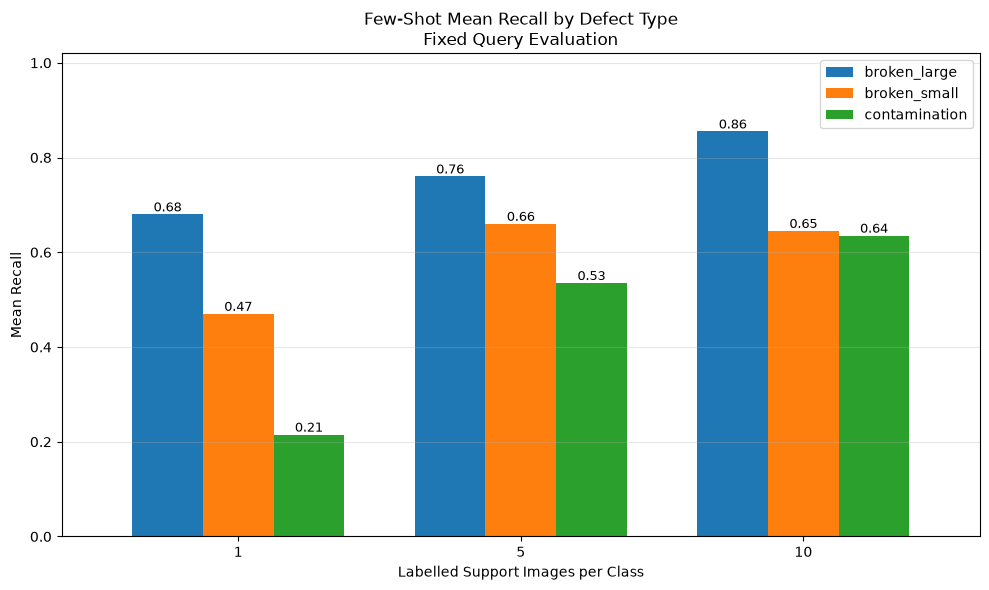

Fixed-query recall figure saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\few_shot_fixed_query_class_recall.png


In [51]:
fixed_recall_plot_df = (
    fixed_query_summary_df[
        [
            "shots",
            "broken_large_recall_mean",
            "broken_small_recall_mean",
            "contamination_recall_mean",
        ]
    ]
    .set_index("shots")
    .rename(
        columns={
            "broken_large_recall_mean": "broken_large",
            "broken_small_recall_mean": "broken_small",
            "contamination_recall_mean": "contamination",
        }
    )
)

axis = fixed_recall_plot_df.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75,
)

axis.set_title(
    "Few-Shot Mean Recall by Defect Type\n"
    "Fixed Query Evaluation"
)

axis.set_xlabel("Labelled Support Images per Class")
axis.set_ylabel("Mean Recall")
axis.set_ylim(0, 1.02)
axis.grid(axis="y", alpha=0.3)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.2f",
        label_type="edge",
        fontsize=9,
    )

plt.xticks(rotation=0)
plt.tight_layout()

fixed_recall_figure_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "few_shot_fixed_query_class_recall.png"
)

plt.savefig(
    fixed_recall_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Fixed-query recall figure saved to:\n"
    f"{fixed_recall_figure_path}"
)

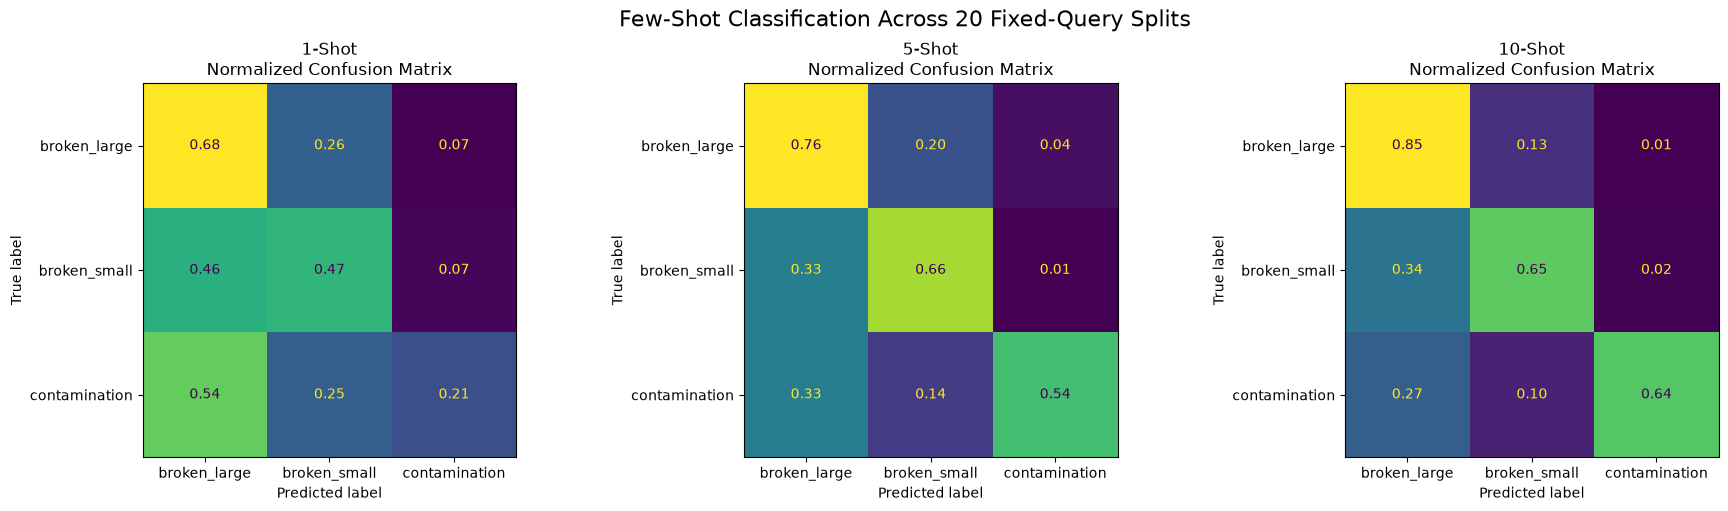

Aggregate confusion matrices saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\few_shot_fixed_query_confusion_matrices.png


In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

figure, axes = plt.subplots(
    1,
    len(SHOT_COUNTS),
    figsize=(18, 5),
    constrained_layout=True,
)

for axis, shot_count in zip(
    axes,
    SHOT_COUNTS,
):
    confusion = fixed_query_confusions[
        shot_count
    ].astype(np.float64)

    normalized_confusion = (
        confusion
        / confusion.sum(
            axis=1,
            keepdims=True,
        )
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=normalized_confusion,
        display_labels=DEFECT_TYPES,
    )

    display.plot(
        ax=axis,
        values_format=".2f",
        colorbar=False,
    )

    axis.set_title(
        f"{shot_count}-Shot\n"
        "Normalized Confusion Matrix"
    )

    axis.tick_params(
        axis="x",
        rotation=0,
    )

figure.suptitle(
    "Few-Shot Classification Across 20 Fixed-Query Splits",
    fontsize=16,
)

aggregate_confusion_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "few_shot_fixed_query_confusion_matrices.png"
)

plt.savefig(
    aggregate_confusion_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Aggregate confusion matrices saved to:\n"
    f"{aggregate_confusion_path}"
)

In [54]:
final_few_shot_summary_df = (
    fixed_query_summary_df[
        [
            "shots",
            "runs",
            "query_images",
            "accuracy_mean",
            "accuracy_std",
            "macro_f1_mean",
            "macro_f1_std",
            "broken_large_recall_mean",
            "broken_small_recall_mean",
            "contamination_recall_mean",
        ]
    ]
    .copy()
)

final_few_shot_summary_df[
    [
        "accuracy_mean",
        "accuracy_std",
        "macro_f1_mean",
        "macro_f1_std",
        "broken_large_recall_mean",
        "broken_small_recall_mean",
        "contamination_recall_mean",
    ]
] *= 100

final_few_shot_summary_df = (
    final_few_shot_summary_df.rename(
        columns={
            "shots": "shots_per_class",
            "query_images": "query_images_per_run",
            "accuracy_mean": "accuracy_mean_percent",
            "accuracy_std": "accuracy_std_percent",
            "macro_f1_mean": "macro_f1_mean_percent",
            "macro_f1_std": "macro_f1_std_percent",
            "broken_large_recall_mean": (
                "broken_large_recall_percent"
            ),
            "broken_small_recall_mean": (
                "broken_small_recall_percent"
            ),
            "contamination_recall_mean": (
                "contamination_recall_percent"
            ),
        }
    )
)

final_few_shot_summary_df = (
    final_few_shot_summary_df.round(2)
)

final_few_shot_summary_df

,shots_per_class,runs,query_images_per_run,accuracy_mean_percent,accuracy_std_percent,macro_f1_mean_percent,macro_f1_std_percent,broken_large_recall_percent,broken_small_recall_percent,contamination_recall_percent
0,1,20,30.0,45.50,10.33,40.90,11.78,68.0,47.0,21.5
1,5,20,30.0,65.17,9.52,64.03,11.08,76.0,66.0,53.5
2,10,20,30.0,71.17,6.95,70.62,7.95,85.5,64.5,63.5


In [55]:
final_few_shot_table_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "few_shot_portfolio_summary.csv"
)

final_few_shot_summary_df.to_csv(
    final_few_shot_table_path,
    index=False,
)

print(
    "Portfolio-ready few-shot table saved to:\n"
    f"{final_few_shot_table_path}"
)

Portfolio-ready few-shot table saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\few_shot_portfolio_summary.csv
